# Module 8 — Phát hiện Offer Lương Bất Thường bằng Isolation Forest

## Mục tiêu
Module này xây dựng hệ thống phát hiện bất thường (anomaly detection) cho các offer lương, trả lời câu hỏi:  
**"Offer này có bất thường không so với hồ sơ ứng viên và nhóm tương đồng?"**

## Luồng xử lý
```
Input: lgbm_predictions.csv + knn_peer_benchmark_results.csv + offer_predictions.csv
   ↓
[Build Anomaly Features]
   ↓
[Global Isolation Forest] → anomaly_score toàn cục
   ↓
[Peer-Group Isolation Forest] → anomaly_score trong nhóm
   ↓
[Classify: underpaid / overpaid / structural / normal]
   ↓
[Explain by Deviation: feature nào lệch nhiều nhất]
   ↓
[Sensitivity Analysis: contamination = 0.03, 0.05, 0.10]
   ↓
Output: tables/ + figures/ + module_08_offer_anomaly_report.md
```

## Thư viện
- `pandas`, `numpy`, `sklearn`, `matplotlib`, `joblib`
- Không dùng `seaborn`
- Biểu đồ học thuật đen trắng, font serif

---
## Cell 1 — Import thư viện

In [23]:
import os
import warnings
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("[OK] Thư viện đã được import.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  sklearn : {__import__('sklearn').__version__}")

[OK] Thư viện đã được import.
  pandas  : 3.0.3
  numpy   : 2.4.6
  sklearn : 1.6.1


---
## Cell 2 — Cấu hình chung

Mọi tham số quan trọng được khai báo tập trung ở đây. Thay đổi tại đây sẽ ảnh hưởng toàn bộ notebook.

In [24]:
# ============================================================
#   CẤU HÌNH CHUNG — MODULE 8: OFFER ANOMALY DETECTION
# ============================================================

# --- Đường dẫn dữ liệu chính ---
# Ưu tiên: lgbm_predictions.csv (có y_pred, y_pred_p10, p50, p90)
DATA_PATH = "lgbm_predictions.csv"

# --- Các bảng bổ sung từ module trước ---
OPTIONAL_TABLE_PATHS = {
    "peer_benchmark"   : "knn_peer_benchmark_results.csv",
    "offer_assessment" : "offer_assessment_outputs/offer_predictions.csv",
    "negotiation"      : "negotiation_outputs/negotiation_recommendations.csv",
    "causal_ranking"   : "causal_ranking_outputs/causal_ranking_report.json",
    "preprocessed"     : "preprocessing_salary_outputs/X_train_processed.npz",
}

# --- Thư mục output ---
OUTPUT_DIR      = Path("module_08_offer_anomaly")
TABLE_DIR       = OUTPUT_DIR / "tables"
FIGURE_DIR      = OUTPUT_DIR / "figures"
MODEL_DIR       = OUTPUT_DIR / "models"

for d in [TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Isolation Forest ---
RANDOM_STATE         = 42
CONTAMINATION_GRID   = [0.03, 0.05, 0.10]   # sensitivity analysis
DEFAULT_CONTAMINATION = 0.05
MIN_GROUP_SIZE        = 50                   # nhóm nhỏ hơn → fallback
TOP_N_FEATURES        = 10                   # top biến lệch nhiều nhất

# --- Ngưỡng phân loại anomaly ---
LOW_RATIO_THRESHOLD   = 0.85   # offer/peer_median < 0.85 → underpaid
HIGH_RATIO_THRESHOLD  = 1.15   # offer/peer_median > 1.15 → overpaid

# --- Tên cột tự động nhận diện ---
# Sẽ được xác định trong bước đọc dữ liệu
CANDIDATE_ID_COL  = None
SALARY_COL        = None    # target gốc (ln_salary hoặc salary)
OFFER_COL         = None    # offer_salary nếu có
PRED_COL          = None    # y_pred từ Module 1
PEER_MEDIAN_COL   = None    # peer_median từ Module 2

print("[OK] Cấu hình khởi tạo xong.")
print(f"  Output dir     : {OUTPUT_DIR.resolve()}")
print(f"  Contamination  : {DEFAULT_CONTAMINATION} (grid: {CONTAMINATION_GRID})")
print(f"  Min group size : {MIN_GROUP_SIZE}")

[OK] Cấu hình khởi tạo xong.
  Output dir     : C:\Users\AD\OneDrive\Tài liệu\2025.2\DSS\module_08_offer_anomaly
  Contamination  : 0.05 (grid: [0.03, 0.05, 0.1])
  Min group size : 50


---
## Cell 3 — Đọc dữ liệu chính và các bảng bổ sung

Notebook tự động nhận diện:
- `salary_col` / `ln_salary` / `offer_salary`
- `y_pred`, `y_pred_p50` từ Module 1
- `peer_median` từ Module 2
- Các bảng thiếu → in cảnh báo và tiếp tục

In [25]:
# ============================================================
#   ĐỌC DỮ LIỆU CHÍNH
# ============================================================

def load_main_data(path: str) -> pd.DataFrame:
    """Load file CSV chính. Hỗ trợ nhiều tên file thông dụng."""
    candidates = [
        path,
        "lgbm_predictions.csv",
        "data_model_input.csv",
        "preprocessed_salary_data.csv",
    ]
    for p in candidates:
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f"[OK] Đọc dữ liệu chính: {p}  ({df.shape[0]:,} dòng × {df.shape[1]} cột)")
            return df
    raise FileNotFoundError(
        f"[ERROR] Không tìm thấy file dữ liệu chính. "
        f"Đã thử: {candidates}"
    )

df_main = load_main_data(DATA_PATH)

# ============================================================
#   ĐỌC CÁC BẢNG BỔ SUNG
# ============================================================

optional_tables = {}
for name, path in OPTIONAL_TABLE_PATHS.items():
    if not os.path.exists(path):
        print(f"  [WARN] Bảng '{name}' không tìm thấy tại '{path}'. Bỏ qua.")
        optional_tables[name] = None
        continue
    try:
        if path.endswith(".json"):
            with open(path) as f:
                optional_tables[name] = json.load(f)
        elif path.endswith(".npz"):
            optional_tables[name] = np.load(path, allow_pickle=True)
        else:
            optional_tables[name] = pd.read_csv(path)
        print(f"  [OK] Đọc bảng '{name}': {path}")
    except Exception as e:
        print(f"  [WARN] Đọc '{name}' thất bại: {e}. Bỏ qua.")
        optional_tables[name] = None

# ============================================================
#   TỰ ĐỘNG NHẬN DIỆN CÁC CỘT QUAN TRỌNG
# ============================================================

def auto_detect_columns(df: pd.DataFrame, opt_tables: dict) -> dict:
    cols = df.columns.str.lower().tolist()
    orig = df.columns.tolist()

    def find_col(*names):
        for n in names:
            for c_low, c_orig in zip(cols, orig):
                if n.lower() in c_low:
                    return c_orig
        return None

    info = {
        "candidate_id"  : find_col("candidate_id", "id", "index"),
        "salary_col"    : find_col("ln_salary", "log_salary", "salary"),
        "offer_col"     : find_col("offer_salary", "offer"),
        "pred_col"      : find_col("y_pred", "pred_salary", "predicted"),
        "pred_p50_col"  : find_col("y_pred_p50", "p50"),
        "pred_p10_col"  : find_col("y_pred_p10", "p10"),
        "pred_p90_col"  : find_col("y_pred_p90", "p90"),
        "peer_median_col": None,
        "peer_std_col"  : None,
    }

    # Merge peer benchmark nếu có
    peer_df = opt_tables.get("peer_benchmark")
    if isinstance(peer_df, pd.DataFrame):
        peer_cols = peer_df.columns.str.lower()
        peer_median = next((c for c in peer_df.columns if 'median' in c.lower()), None)
        peer_std    = next((c for c in peer_df.columns if 'std' in c.lower()), None)
        # Merge vào df_main
        merge_key = info["candidate_id"]
        if merge_key and merge_key in peer_df.columns:
            df = df.merge(peer_df[[merge_key, peer_median, peer_std]].dropna(how='all'),
                          on=merge_key, how='left', suffixes=('', '_peer'))
        else:
            # Merge by position (index)
            for c in [peer_median, peer_std]:
                if c and c not in df.columns:
                    if len(peer_df) == len(df):
                        df[c] = peer_df[c].values
        info["peer_median_col"] = peer_median
        info["peer_std_col"]    = peer_std
        print(f"  [OK] Merge peer benchmark: median='{peer_median}', std='{peer_std}'")

    # Merge offer_assessment nếu có
    offer_df = opt_tables.get("offer_assessment")
    if isinstance(offer_df, pd.DataFrame):
        conf_col = next((c for c in offer_df.columns if 'confidence' in c.lower()), None)
        dec_col  = next((c for c in offer_df.columns if 'decision' in c.lower() or 'label' in c.lower()), None)
        for c in [conf_col, dec_col]:
            if c and c not in df.columns and len(offer_df) == len(df):
                df[c] = offer_df[c].values
        info["confidence_col"] = conf_col
        info["decision_col"]   = dec_col
        print(f"  [OK] Merge offer assessment: confidence='{conf_col}', decision='{dec_col}'")

    # Nếu không có offer_col, dùng salary làm đại diện
    if not info["offer_col"]:
        info["offer_col"] = info["salary_col"]
        print("  [INFO] Không tìm thấy offer_salary. Dùng salary làm biến đại diện.")

    return info, df

COL_INFO, df_main = auto_detect_columns(df_main, optional_tables)

print("\n[INFO] Cột nhận diện:")
for k, v in COL_INFO.items():
    print(f"  {k:20s}: {v}")

# Cập nhật biến global
CANDIDATE_ID_COL = COL_INFO.get("candidate_id")
SALARY_COL       = COL_INFO.get("salary_col")
OFFER_COL        = COL_INFO.get("offer_col")
PRED_COL         = COL_INFO.get("pred_col") or COL_INFO.get("pred_p50_col")
PEER_MEDIAN_COL  = COL_INFO.get("peer_median_col")
IS_LOG_SCALE     = SALARY_COL and 'ln' in SALARY_COL.lower()

print(f"\n  [INFO] Target ở log-scale? {IS_LOG_SCALE}")

[OK] Đọc dữ liệu chính: lgbm_predictions.csv  (50,000 dòng × 6 cột)
  [OK] Đọc bảng 'peer_benchmark': knn_peer_benchmark_results.csv
  [WARN] Bảng 'offer_assessment' không tìm thấy tại 'offer_assessment_outputs/offer_predictions.csv'. Bỏ qua.
  [OK] Đọc bảng 'negotiation': negotiation_outputs/negotiation_recommendations.csv
  [WARN] Đọc 'causal_ranking' thất bại: 'charmap' codec can't decode byte 0x8d in position 424: character maps to <undefined>. Bỏ qua.
  [OK] Đọc bảng 'preprocessed': preprocessing_salary_outputs/X_train_processed.npz
  [OK] Merge peer benchmark: median='peer_median', std='peer_std'
  [INFO] Không tìm thấy offer_salary. Dùng salary làm biến đại diện.

[INFO] Cột nhận diện:
  candidate_id        : residual
  salary_col          : None
  offer_col           : None
  pred_col            : y_pred
  pred_p50_col        : y_pred_p50
  pred_p10_col        : y_pred_p10
  pred_p90_col        : y_pred_p90
  peer_median_col     : peer_median
  peer_std_col        : peer_std

 

---
## Cell 4 — Tóm tắt dữ liệu đầu vào

Kiểm tra chất lượng dữ liệu trước khi huấn luyện Isolation Forest.

In [26]:
# ============================================================
#   TÓM TẮT DỮ LIỆU ĐẦU VÀO
# ============================================================

print("=" * 60)
print("TỔNG QUAN DỮ LIỆU")
print("=" * 60)
print(f"  Số dòng       : {len(df_main):,}")
print(f"  Số cột        : {df_main.shape[1]}")

missing_summary = df_main.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
print(f"  Cột có missing: {len(missing_summary)} / {df_main.shape[1]}")
if len(missing_summary) > 0:
    for col, cnt in missing_summary.items():
        print(f"    {col}: {cnt} ({100*cnt/len(df_main):.1f}%)")

# Phân phối offer/salary
if OFFER_COL and OFFER_COL in df_main.columns:
    s = df_main[OFFER_COL].dropna()
    if IS_LOG_SCALE:
        s_exp = np.exp(s)
        print(f"\n  Phân phối {OFFER_COL} (log-scale):")
        print(f"    Min={s.min():.3f}, Max={s.max():.3f}, Mean={s.mean():.3f}")
        print(f"  Phân phối salary (exp):")
        print(f"    Min={s_exp.min():,.0f}, P25={s_exp.quantile(0.25):,.0f}, "
              f"Median={s_exp.median():,.0f}, P75={s_exp.quantile(0.75):,.0f}, Max={s_exp.max():,.0f}")
    else:
        print(f"\n  Phân phối {OFFER_COL}:")
        print(f"    Min={s.min():,.0f}, P25={s.quantile(0.25):,.0f}, "
              f"Median={s.median():,.0f}, P75={s.quantile(0.75):,.0f}, Max={s.max():,.0f}")

# Các cột phân loại quan trọng
for col in ['job_title', 'job_role', 'location', 'company_size', 'industry']:
    if col in df_main.columns:
        n_unique = df_main[col].nunique()
        print(f"\n  Số nhóm '{col}': {n_unique}")

# Tạo bảng summary
summary_records = []
for col in df_main.columns:
    summary_records.append({
        "column"   : col,
        "dtype"    : str(df_main[col].dtype),
        "n_missing": int(df_main[col].isnull().sum()),
        "pct_missing": round(100*df_main[col].isnull().sum()/len(df_main), 2),
        "n_unique" : int(df_main[col].nunique()),
    })
df_summary = pd.DataFrame(summary_records)
df_summary.to_csv(TABLE_DIR / "table_01_input_summary.csv", index=False)
print(f"\n  [Saved] table_01_input_summary.csv")

TỔNG QUAN DỮ LIỆU
  Số dòng       : 50,000
  Số cột        : 8
  Cột có missing: 0 / 8

  [Saved] table_01_input_summary.csv


---
## Cell 5 — Xây dựng đặc trưng (Feature Engineering cho Anomaly Detection)

Hàm `build_anomaly_features()` tạo không gian đặc trưng cho Isolation Forest:
- Các ratio so với benchmark/prediction
- Các feature hồ sơ ứng viên
- Encoding categorical bằng frequency encoding
- Impute missing → Scale chuẩn hóa

In [27]:
# ============================================================
#   FUNCTION: build_anomaly_features(df)
# ============================================================

def build_anomaly_features(
    df: pd.DataFrame,
    offer_col: str   = None,
    pred_col: str    = None,
    peer_median_col: str = None,
    is_log_scale: bool = False,
) -> tuple:
    """
    Tạo ma trận đặc trưng X cho Isolation Forest.

    Parameters
    ----------
    df              : DataFrame gốc
    offer_col       : cột offer/salary
    pred_col        : cột y_pred từ Module 1
    peer_median_col : cột peer_median từ Module 2
    is_log_scale    : True nếu các cột salary đang ở log-scale

    Returns
    -------
    X_scaled  : np.ndarray — đặc trưng đã chuẩn hóa
    feature_names : list[str]
    preprocessing_pipeline : sklearn Pipeline (imputer + scaler)
    df_features : DataFrame gốc (chưa scale) để diễn giải
    """
    feat = pd.DataFrame(index=df.index)
    feature_meta = []  # (tên, mô tả)

    # ── 1. Salary / Offer ────────────────────────────────────
    def to_nominal(series, is_log):
        """Chuyển về thang tuyến tính nếu log."""
        return np.exp(series) if is_log else series

    if offer_col and offer_col in df.columns:
        offer_vals = to_nominal(df[offer_col], is_log_scale)
        feat['offer_salary'] = offer_vals
        feature_meta.append(('offer_salary', 'Mức lương offer'))
    else:
        offer_vals = None
        print("  [WARN] Không tìm thấy offer_col.")

    # ── 2. Predicted salary ──────────────────────────────────
    if pred_col and pred_col in df.columns:
        pred_vals = to_nominal(df[pred_col], is_log_scale)
        feat['predicted_salary'] = pred_vals
        feature_meta.append(('predicted_salary', 'Lương dự báo từ Module 1'))

        if offer_vals is not None:
            ratio = offer_vals / pred_vals.replace(0, np.nan)
            feat['offer_to_predicted_ratio'] = ratio
            feat['salary_gap_to_prediction'] = offer_vals - pred_vals
            feature_meta += [
                ('offer_to_predicted_ratio', 'Tỷ lệ offer/dự báo'),
                ('salary_gap_to_prediction', 'Khoảng cách offer − dự báo'),
            ]

    # ── 3. Peer benchmark ────────────────────────────────────
    if peer_median_col and peer_median_col in df.columns:
        peer_vals = to_nominal(df[peer_median_col], is_log_scale)
        feat['peer_median_salary'] = peer_vals
        feature_meta.append(('peer_median_salary', 'Median lương nhóm tương đồng'))

        if offer_vals is not None:
            ratio_p = offer_vals / peer_vals.replace(0, np.nan)
            feat['offer_to_peer_ratio']  = ratio_p
            feat['salary_gap_to_peer']   = offer_vals - peer_vals
            feature_meta += [
                ('offer_to_peer_ratio', 'Tỷ lệ offer/median nhóm'),
                ('salary_gap_to_peer', 'Khoảng cách offer − median nhóm'),
            ]

    # ── 4. Prediction interval width (uncertainty) ───────────
    p10_col = COL_INFO.get('pred_p10_col')
    p90_col = COL_INFO.get('pred_p90_col')
    if p10_col and p90_col and p10_col in df.columns and p90_col in df.columns:
        pi_width = to_nominal(df[p90_col], is_log_scale) - to_nominal(df[p10_col], is_log_scale)
        feat['prediction_interval_width'] = pi_width
        feature_meta.append(('prediction_interval_width', 'Độ rộng khoảng dự báo P10-P90'))

    # ── 5. Hồ sơ ứng viên ────────────────────────────────────
    numeric_profile_cols = [
        'experience_years', 'years_experience',
        'skills_count', 'number_of_skills',
        'certifications',
    ]
    for c in numeric_profile_cols:
        if c in df.columns:
            feat[c] = df[c]
            feature_meta.append((c, f'Hồ sơ: {c}'))

    # ── 6. Categorical — Ordinal encoding ────────────────────
    ordinal_mappings = {
        'education_level': [
            'High School', 'Associate', 'Bachelor', 'Bachelor\'s',
            'Master', 'Master\'s', 'PhD', 'Doctorate'
        ],
        'company_size': ['Small', 'Medium', 'Large', 'Enterprise'],
        'remote_work' : ['No', 'Hybrid', 'Yes'],
        'remote_option': ['No', 'Hybrid', 'Yes'],
    }
    for col, order in ordinal_mappings.items():
        if col in df.columns:
            mapping = {v: i for i, v in enumerate(order)}
            feat[f'{col}_enc'] = df[col].map(mapping)
            feature_meta.append((f'{col}_enc', f'Encoded: {col}'))

    # ── 7. Categorical — Frequency encoding ──────────────────
    freq_cols = ['job_title', 'job_role', 'location', 'industry']
    for col in freq_cols:
        if col in df.columns:
            freq_map = df[col].value_counts(normalize=True)
            feat[f'{col}_freq'] = df[col].map(freq_map)
            feature_meta.append((f'{col}_freq', f'Frequency encoding: {col}'))

    # ── 8. Pipeline: Impute → Scale ──────────────────────────
    feature_names = [f[0] for f in feature_meta]
    X_raw = feat[feature_names].values.astype(float)

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    X_scaled = pipe.fit_transform(X_raw)

    # Bảng feature meta
    df_feat_meta = pd.DataFrame(feature_meta, columns=['feature', 'description'])
    df_feat_meta['n_missing'] = feat[feature_names].isnull().sum().values

    print(f"[OK] build_anomaly_features: {len(feature_names)} features, shape={X_scaled.shape}")
    return X_scaled, feature_names, pipe, feat

# Chạy
X_scaled, FEATURE_NAMES, PREPROC_PIPE, df_features = build_anomaly_features(
    df_main,
    offer_col       = OFFER_COL,
    pred_col        = PRED_COL,
    peer_median_col = PEER_MEDIAN_COL,
    is_log_scale    = IS_LOG_SCALE,
)

# Lưu feature meta
df_feat_meta = pd.DataFrame({'feature': FEATURE_NAMES})
df_feat_meta.to_csv(TABLE_DIR / "table_02_anomaly_features_used.csv", index=False)
print("  [Saved] table_02_anomaly_features_used.csv")
print("\n  Features sử dụng:")
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f"    {i:2d}. {f}")

  [WARN] Không tìm thấy offer_col.
[OK] build_anomaly_features: 3 features, shape=(50000, 3)
  [Saved] table_02_anomaly_features_used.csv

  Features sử dụng:
     1. predicted_salary
     2. peer_median_salary
     3. prediction_interval_width


---
## Cell 6 — Tầng 1: Global Isolation Forest

Phát hiện bất thường **toàn cục** — không phụ thuộc nhóm. Isolation Forest hoạt động bằng cách:
1. Xây nhiều cây quyết định ngẫu nhiên (isolation trees)
2. Điểm bất thường = trung bình độ dài đường đi ngắn đến mỗi quan sát
3. Quan sát **dễ bị cô lập** (đường đi ngắn) = **bất thường cao**

In [28]:
# ============================================================
#   FUNCTION: fit_global_isolation_forest(X, contamination)
# ============================================================

def fit_global_isolation_forest(
    X: np.ndarray,
    contamination: float = DEFAULT_CONTAMINATION,
    random_state: int    = RANDOM_STATE,
) -> tuple:
    """
    Huấn luyện Global Isolation Forest.

    Returns
    -------
    model       : IsolationForest đã fit
    scores_dict : dict với các mảng kết quả
    """
    model = IsolationForest(
        n_estimators  = 200,
        contamination = contamination,
        max_samples   = 'auto',
        random_state  = random_state,
        n_jobs        = -1,
    )
    model.fit(X)

    # score_samples: score thô [âm nhất = bất thường nhất]
    raw_scores  = model.score_samples(X)          # [-∞, 0], thấp hơn = bất thường hơn
    labels      = model.predict(X)                # -1 = outlier, 1 = normal

    # Quy đổi sang anomaly_risk_score [0,1], cao hơn = bất thường hơn
    # Công thức: min-max trên âm của score gốc
    neg_scores  = -raw_scores
    risk_scores = (neg_scores - neg_scores.min()) / (neg_scores.max() - neg_scores.min() + 1e-9)

    # Rank và percentile
    rank        = pd.Series(risk_scores).rank(method='min', ascending=False).astype(int).values
    percentile  = pd.Series(risk_scores).rank(pct=True).values

    scores_dict = {
        'global_anomaly_score_raw'  : raw_scores,
        'global_anomaly_risk_score' : risk_scores,
        'global_anomaly_label'      : labels,      # -1 or 1
        'global_is_anomaly'         : (labels == -1).astype(int),
        'global_anomaly_rank'       : rank,
        'global_anomaly_percentile' : np.round(percentile, 4),
    }
    return model, scores_dict

# Chạy
global_model, global_scores = fit_global_isolation_forest(
    X_scaled, contamination=DEFAULT_CONTAMINATION
)

# Gắn vào df_main
for k, v in global_scores.items():
    df_main[k] = v

n_global_anomaly = df_main['global_is_anomaly'].sum()
print(f"[OK] Global Isolation Forest:")
print(f"  contamination = {DEFAULT_CONTAMINATION}")
print(f"  Số offer bị flag: {n_global_anomaly:,} / {len(df_main):,} "
      f"({100*n_global_anomaly/len(df_main):.1f}%)")
print(f"  Anomaly risk score — Mean: {df_main['global_anomaly_risk_score'].mean():.4f}, "
      f"Max: {df_main['global_anomaly_risk_score'].max():.4f}")

# Lưu kết quả
cols_to_save = [CANDIDATE_ID_COL] if CANDIDATE_ID_COL else []
cols_to_save += [OFFER_COL, PRED_COL, PEER_MEDIAN_COL] if OFFER_COL else []
cols_to_save += list(global_scores.keys())
cols_to_save = [c for c in cols_to_save if c and c in df_main.columns]
df_main[cols_to_save].to_csv(TABLE_DIR / "table_03_global_anomaly_results.csv", index=True)
print("  [Saved] table_03_global_anomaly_results.csv")

# Lưu model
joblib.dump(global_model,  MODEL_DIR / "global_isolation_forest.joblib")
joblib.dump(PREPROC_PIPE,  MODEL_DIR / "anomaly_preprocessing_pipeline.joblib")
print("  [Saved] global_isolation_forest.joblib + anomaly_preprocessing_pipeline.joblib")

[OK] Global Isolation Forest:
  contamination = 0.05
  Số offer bị flag: 2,500 / 50,000 (5.0%)
  Anomaly risk score — Mean: 0.1815, Max: 1.0000
  [Saved] table_03_global_anomaly_results.csv
  [Saved] global_isolation_forest.joblib + anomaly_preprocessing_pipeline.joblib


---
## Cell 7 — Tầng 2: Peer-Group Isolation Forest

Phát hiện bất thường **trong từng nhóm tương đồng** (peer group).  
Offer *bình thường toàn cục* nhưng *bất thường trong nhóm* là tín hiệu quan trọng hơn.

**Fallback hierarchy:**
```
job_role + experience_bin + location  (ưu tiên)
    ↓ (nếu < MIN_GROUP_SIZE)
job_role + experience_bin
    ↓
job_role
    ↓
Global model
```

In [29]:
# ============================================================
#   FUNCTION: create_peer_group_key(df)
# ============================================================

def create_peer_group_key(df: pd.DataFrame) -> pd.Series:
    """Tạo key nhóm từ các cột phân loại có sẵn."""
    # Tìm cột kinh nghiệm
    exp_col = next((c for c in df.columns if 'experience' in c.lower() or 'exp' in c.lower()
                    and df[c].dtype in [np.float64, np.int64]), None)
    # Tạo bin kinh nghiệm nếu có
    if exp_col:
        df = df.copy()
        df['_exp_bin'] = pd.cut(
            df[exp_col],
            bins  = [0, 2, 5, 10, 20, 100],
            labels= ['0-2yr', '3-5yr', '6-10yr', '11-20yr', '20+yr'],
            right = True
        ).astype(str)
    else:
        df = df.copy()
        df['_exp_bin'] = 'unknown'

    # Hierarchy thử theo thứ tự
    role_col  = next((c for c in ['job_role', 'job_title'] if c in df.columns), None)
    loc_col   = next((c for c in ['location', 'city', 'region'] if c in df.columns), None)
    size_col  = next((c for c in ['company_size'] if c in df.columns), None)

    parts = []
    if role_col: parts.append(df[role_col].astype(str))
    parts.append(df['_exp_bin'].astype(str))
    if loc_col : parts.append(df[loc_col].astype(str))

    return parts, df


# ============================================================
#   FUNCTION: fit_peer_group_isolation_forest(df, X, group_cols)
# ============================================================

def fit_peer_group_isolation_forest(
    df: pd.DataFrame,
    X:  np.ndarray,
    group_cols:   list   = None,
    contamination: float = DEFAULT_CONTAMINATION,
    min_group_size: int  = MIN_GROUP_SIZE,
    random_state:  int   = RANDOM_STATE,
) -> tuple:
    """
    Với mỗi peer group đủ lớn, fit Isolation Forest riêng.
    Nếu nhóm nhỏ → fallback theo hierarchy.

    Returns
    -------
    df_result    : DataFrame với peer anomaly scores
    peer_models  : dict {group_key: model}
    group_summary: DataFrame thống kê từng nhóm
    """
    part_series_list, df_aug = create_peer_group_key(df)

    # Tạo group keys theo fallback hierarchy
    fallback_levels = []
    # Level 0: role + exp + location (full)
    if len(part_series_list) >= 3:
        fallback_levels.append(part_series_list)          # all parts
        fallback_levels.append(part_series_list[:2])      # role + exp
        fallback_levels.append(part_series_list[:1])      # role only
    elif len(part_series_list) == 2:
        fallback_levels.append(part_series_list)
        fallback_levels.append(part_series_list[:1])
    else:
        fallback_levels.append(part_series_list)

    # Khởi tạo output
    n = len(df)
    peer_risk_scores  = np.full(n, np.nan)
    peer_labels       = np.full(n, 1, dtype=int)   # default: normal
    peer_group_keys   = np.full(n, 'global', dtype=object)
    peer_group_sizes  = np.full(n, 0, dtype=int)
    peer_models_dict  = {}

    assigned = np.zeros(n, dtype=bool)

    for level_idx, parts in enumerate(fallback_levels):
        group_key_series = parts[0].copy()
        for p in parts[1:]:
            group_key_series = group_key_series + '|' + p

        for grp_val, idx in df.groupby(group_key_series.values).groups.items():
            idx_arr = np.array(idx)
            # Chỉ xử lý các dòng chưa được assign ở level trước
            unassigned_mask = ~assigned[idx_arr]
            idx_unassigned  = idx_arr[unassigned_mask]

            if len(idx_unassigned) < min_group_size:
                continue  # sẽ xử lý ở level fallback hoặc global

            X_grp = X[idx_unassigned]

            # Fit
            grp_model = IsolationForest(
                n_estimators   = 100,
                contamination  = contamination,
                random_state   = random_state,
                n_jobs         = -1,
            )
            grp_model.fit(X_grp)

            raw   = grp_model.score_samples(X_grp)
            labs  = grp_model.predict(X_grp)
            neg_r = -raw
            risk  = (neg_r - neg_r.min()) / (neg_r.max() - neg_r.min() + 1e-9)

            peer_risk_scores[idx_unassigned] = risk
            peer_labels[idx_unassigned]       = labs
            peer_group_keys[idx_unassigned]   = grp_val
            peer_group_sizes[idx_unassigned]  = len(idx_unassigned)
            assigned[idx_unassigned]          = True
            peer_models_dict[grp_val]         = grp_model

    # Fallback: global model cho các dòng còn lại
    unassigned_idx = np.where(~assigned)[0]
    if len(unassigned_idx) > 0:
        print(f"  [INFO] {len(unassigned_idx)} dòng fallback sang global model.")
        global_risk  = df_main.loc[unassigned_idx, 'global_anomaly_risk_score'].values
        global_lbl   = df_main.loc[unassigned_idx, 'global_anomaly_label'].values
        peer_risk_scores[unassigned_idx] = global_risk
        peer_labels[unassigned_idx]       = global_lbl
        peer_group_keys[unassigned_idx]   = 'GLOBAL_FALLBACK'
        peer_group_sizes[unassigned_idx]  = len(unassigned_idx)

    # Kết quả
    df_result = pd.DataFrame({
        'peer_anomaly_risk_score' : np.round(peer_risk_scores, 4),
        'peer_anomaly_label'      : peer_labels,
        'peer_is_anomaly'         : (peer_labels == -1).astype(int),
        'peer_group_key'          : peer_group_keys,
        'peer_group_size'         : peer_group_sizes,
    }, index=df.index)

    # Group summary
    grp_sum = df_result.groupby('peer_group_key').agg(
        n_members       = ('peer_group_size', 'first'),
        n_anomaly       = ('peer_is_anomaly', 'sum'),
        mean_risk_score = ('peer_anomaly_risk_score', 'mean'),
    ).reset_index()
    grp_sum['pct_anomaly'] = (grp_sum['n_anomaly'] / grp_sum['n_members'] * 100).round(1)

    return df_result, peer_models_dict, grp_sum


# Chạy
df_peer, peer_models, df_group_summary = fit_peer_group_isolation_forest(
    df_main, X_scaled, contamination=DEFAULT_CONTAMINATION
)

# Gắn vào df_main
for col in df_peer.columns:
    df_main[col] = df_peer[col].values

n_peer_anomaly = df_main['peer_is_anomaly'].sum()
print(f"\n[OK] Peer-Group Isolation Forest:")
print(f"  Số nhóm được fit riêng : {len(peer_models)}")
print(f"  Số offer bị flag (peer): {n_peer_anomaly:,} / {len(df_main):,} "
      f"({100*n_peer_anomaly/len(df_main):.1f}%)")

# Lưu
peer_cols = [CANDIDATE_ID_COL] if CANDIDATE_ID_COL else []
peer_cols += [OFFER_COL] if OFFER_COL else []
peer_cols += list(df_peer.columns)
peer_cols = [c for c in peer_cols if c and c in df_main.columns]
df_main[peer_cols].to_csv(TABLE_DIR / "table_04_peer_group_anomaly_results.csv", index=True)
df_group_summary.to_csv(TABLE_DIR / "table_05_peer_group_summary.csv", index=False)
print("  [Saved] table_04_peer_group_anomaly_results.csv")
print("  [Saved] table_05_peer_group_summary.csv")

# Lưu peer models
joblib.dump(peer_models, MODEL_DIR / "peer_group_isolation_forests.joblib")
print("  [Saved] peer_group_isolation_forests.joblib")


[OK] Peer-Group Isolation Forest:
  Số nhóm được fit riêng : 1
  Số offer bị flag (peer): 2,500 / 50,000 (5.0%)
  [Saved] table_04_peer_group_anomaly_results.csv
  [Saved] table_05_peer_group_summary.csv
  [Saved] peer_group_isolation_forests.joblib


---
## Cell 8 — Phân loại loại bất thường

Gắn nhãn ngữ nghĩa cho từng offer bị phát hiện:
- **`underpaid_outlier`**: bất thường + lương thấp hơn benchmark rõ rệt
- **`overpaid_outlier`**: bất thường + lương cao hơn benchmark rõ rệt
- **`structural_outlier`**: bất thường nhưng không chênh lương rõ → hồ sơ khác biệt về cấu trúc
- **`normal_offer`**: không bị flag bởi bất kỳ tầng nào

In [30]:
# ============================================================
#   FUNCTION: classify_offer_anomaly(row)
# ============================================================

def classify_offer_anomaly(
    row: pd.Series,
    low_ratio:  float = LOW_RATIO_THRESHOLD,
    high_ratio: float = HIGH_RATIO_THRESHOLD,
) -> str:
    """
    Phân loại anomaly type dựa trên:
    - Kết quả global + peer anomaly flag
    - Tỷ lệ offer so với benchmark (peer_median hoặc predicted)

    Returns: 'underpaid_outlier' | 'overpaid_outlier' | 'structural_outlier' | 'normal_offer'
    """
    is_global_anomaly = row.get('global_is_anomaly', 0) == 1
    is_peer_anomaly   = row.get('peer_is_anomaly',   0) == 1
    is_anomaly        = is_global_anomaly or is_peer_anomaly

    if not is_anomaly:
        return 'normal_offer'

    # Ưu tiên peer ratio, nếu không có dùng predicted ratio
    ratio = None
    gap   = None

    if 'offer_to_peer_ratio' in row and pd.notna(row['offer_to_peer_ratio']):
        ratio = row['offer_to_peer_ratio']
        gap   = row.get('salary_gap_to_peer', np.nan)
    elif 'offer_to_predicted_ratio' in row and pd.notna(row['offer_to_predicted_ratio']):
        ratio = row['offer_to_predicted_ratio']
        gap   = row.get('salary_gap_to_prediction', np.nan)

    if ratio is None:
        # Không có benchmark nào → dùng percentile
        pct = row.get('global_anomaly_percentile', 0.5)
        if pct > 0.8:
            # Điểm bất thường cao nhất → structural
            return 'structural_outlier'
        return 'structural_outlier'

    if ratio < low_ratio:
        return 'underpaid_outlier'
    elif ratio > high_ratio:
        return 'overpaid_outlier'
    else:
        return 'structural_outlier'


# Áp dụng cho toàn bộ dataset
# Đưa các ratio vào df_main nếu chưa có
if 'offer_to_peer_ratio' not in df_main.columns and 'offer_to_peer_ratio' in df_features.columns:
    df_main['offer_to_peer_ratio']       = df_features['offer_to_peer_ratio'].values
    df_main['salary_gap_to_peer']        = df_features['salary_gap_to_peer'].values
if 'offer_to_predicted_ratio' not in df_main.columns and 'offer_to_predicted_ratio' in df_features.columns:
    df_main['offer_to_predicted_ratio']  = df_features['offer_to_predicted_ratio'].values
    df_main['salary_gap_to_prediction']  = df_features['salary_gap_to_prediction'].values

df_main['anomaly_type'] = df_main.apply(classify_offer_anomaly, axis=1)

# Tổng hợp
type_counts = df_main['anomaly_type'].value_counts()
print("[OK] Phân loại anomaly type:")
for t, cnt in type_counts.items():
    print(f"  {t:25s}: {cnt:,} ({100*cnt/len(df_main):.1f}%)")

# Lưu
class_cols = [CANDIDATE_ID_COL, OFFER_COL, PRED_COL, PEER_MEDIAN_COL,
              'global_is_anomaly', 'peer_is_anomaly',
              'offer_to_peer_ratio', 'offer_to_predicted_ratio',
              'anomaly_type']
class_cols = [c for c in class_cols if c and c in df_main.columns]
df_main[class_cols].to_csv(TABLE_DIR / "table_06_anomaly_classification.csv", index=True)
print("  [Saved] table_06_anomaly_classification.csv")

[OK] Phân loại anomaly type:
  normal_offer             : 47,364 (94.7%)
  structural_outlier       : 2,636 (5.3%)
  [Saved] table_06_anomaly_classification.csv


---
## Cell 9 — Kết hợp với Offer Assessment và Decision Support

In [31]:
# ============================================================
#   KẾT HỢP VỚI MODULE 3 & TẠO BẢNG TƯ VẤN
# ============================================================

def get_suggested_action(anomaly_type: str, decision_label: str = None) -> tuple:
    """
    Trả về suggested_action và explanation template.

    Nếu có decision_label từ Module 3, ưu tiên kết hợp.
    """
    action_map = {
        'underpaid_outlier' : (
            'NEGOTIATE_OR_REJECT',
            'Offer thấp bất thường so với nhóm tương đồng và/hoặc dự báo. '
            'Nên đàm phán tăng lương hoặc cân nhắc từ chối.'
        ),
        'overpaid_outlier'  : (
            'VERIFY_THEN_ACCEPT',
            'Offer cao bất thường. Cần xác nhận tính hợp lệ trước khi chấp nhận. '
            'Có thể là offer đặc biệt hoặc lỗi dữ liệu.'
        ),
        'structural_outlier': (
            'MANUAL_REVIEW',
            'Hồ sơ ứng viên hoặc cấu trúc offer khác biệt so với nhóm. '
            'Cần chuyên gia nhân sự kiểm tra thêm.'
        ),
        'normal_offer'      : (
            'EVALUATE_BY_STANDARD_RULE',
            'Offer nằm trong vùng bình thường của nhóm tương đồng.'
        ),
    }

    action, explanation = action_map.get(anomaly_type, ('UNKNOWN', 'Không xác định.'))

    # Override nếu có decision từ Module 3
    if decision_label and anomaly_type == 'normal_offer':
        if 'UNDERPAID' in str(decision_label).upper() or 'LOW' in str(decision_label).upper():
            action = 'NEGOTIATE'
            explanation += f' [Module 3: {decision_label}]'
        elif 'EXCELLENT' in str(decision_label).upper() or 'GOOD' in str(decision_label).upper():
            action = 'ACCEPT'
            explanation += f' [Module 3: {decision_label}]'

    return action, explanation


# Cột decision từ Module 3 nếu có
decision_col   = COL_INFO.get('decision_col')
confidence_col = COL_INFO.get('confidence_col')

# Tạo bảng decision support
records = []
for idx, row in df_main.iterrows():
    dec_label = row.get(decision_col) if decision_col else None
    action, explanation = get_suggested_action(row['anomaly_type'], dec_label)

    rec = {
        'index'              : idx,
        'offer_salary'       : row.get(OFFER_COL),
        'predicted_salary'   : row.get(PRED_COL),
        'peer_median_salary' : row.get(PEER_MEDIAN_COL),
        'global_risk_score'  : row.get('global_anomaly_risk_score'),
        'peer_risk_score'    : row.get('peer_anomaly_risk_score'),
        'anomaly_type'       : row['anomaly_type'],
        'offer_to_peer_ratio': row.get('offer_to_peer_ratio'),
        'suggested_action'   : action,
        'explanation'        : explanation,
    }
    if decision_col:
        rec['module3_decision'] = dec_label
    if confidence_col:
        rec['module3_confidence'] = row.get(confidence_col)
    if CANDIDATE_ID_COL:
        rec['candidate_id'] = row.get(CANDIDATE_ID_COL)
    records.append(rec)

df_decision_support = pd.DataFrame(records)

# Gắn IS_LOG_SCALE: quy đổi sang nominal nếu cần
for col in ['offer_salary', 'predicted_salary', 'peer_median_salary']:
    if col in df_decision_support.columns and IS_LOG_SCALE:
        df_decision_support[col] = np.exp(df_decision_support[col].fillna(np.nan))

df_decision_support.to_csv(TABLE_DIR / "table_07_offer_anomaly_decision_support.csv", index=False)
print(f"[OK] Bảng Decision Support: {len(df_decision_support):,} ứng viên")
print(df_decision_support['suggested_action'].value_counts().to_string())
print("  [Saved] table_07_offer_anomaly_decision_support.csv")

[OK] Bảng Decision Support: 50,000 ứng viên
suggested_action
EVALUATE_BY_STANDARD_RULE    47364
MANUAL_REVIEW                 2636
  [Saved] table_07_offer_anomaly_decision_support.csv


---
## Cell 10 — Diễn giải nguyên nhân bất thường

Isolation Forest không có hệ số như hồi quy. Diễn giải qua:
1. **Z-score** của từng feature trong nhóm
2. **Ratio** so với median nhóm
3. Feature lệch nhiều nhất = nguyên nhân chính

In [32]:
# ============================================================
#   FUNCTION: explain_anomaly_by_deviation(row, reference_profile)
# ============================================================

def explain_anomaly_by_deviation(
    row_features:      pd.Series,
    reference_profile: pd.DataFrame,
    feature_names:     list,
    top_n:             int = TOP_N_FEATURES,
) -> pd.DataFrame:
    """
    Diễn giải tại sao một quan sát bị flag bất thường.

    Parameters
    ----------
    row_features      : Series với các feature của ứng viên (thang gốc, chưa scale)
    reference_profile : DataFrame các quan sát cùng nhóm (để tính median/std)
    feature_names     : danh sách feature đã dùng

    Returns
    -------
    df_deviation : DataFrame ['feature', 'candidate_val', 'group_median',
                               'group_std', 'z_score', 'abs_z_score']
                   sắp xếp theo |z_score| giảm dần
    """
    records = []
    for feat in feature_names:
        if feat not in row_features.index or feat not in reference_profile.columns:
            continue
        val     = row_features[feat]
        grp_med = reference_profile[feat].median()
        grp_std = reference_profile[feat].std()

        if pd.isna(val) or pd.isna(grp_med):
            continue

        z = (val - grp_med) / (grp_std + 1e-9) if grp_std > 0 else 0.0

        # Ratio so với median
        ratio = val / grp_med if grp_med != 0 else np.nan

        records.append({
            'feature'       : feat,
            'candidate_val' : round(float(val), 4),
            'group_median'  : round(float(grp_med), 4),
            'group_std'     : round(float(grp_std), 4),
            'z_score'       : round(float(z), 4),
            'abs_z_score'   : round(abs(float(z)), 4),
            'ratio_to_median': round(float(ratio), 4) if not np.isnan(ratio) else None,
        })

    df_dev = pd.DataFrame(records).sort_values('abs_z_score', ascending=False).head(top_n)
    return df_dev


# Chạy cho toàn bộ dataset — lưu explanation summary
explanation_records = []

# Chỉ chạy cho các anomaly để tiết kiệm thời gian
anomaly_mask = df_main['anomaly_type'] != 'normal_offer'
df_anomaly   = df_main[anomaly_mask].copy()

print(f"Đang diễn giải {anomaly_mask.sum()} trường hợp bất thường...")

for idx, row in df_anomaly.iterrows():
    grp_key = row.get('peer_group_key', 'GLOBAL_FALLBACK')

    # Reference profile: cùng peer group hoặc toàn bộ
    if grp_key and grp_key != 'GLOBAL_FALLBACK' and 'peer_group_key' in df_main.columns:
        ref_mask = df_main['peer_group_key'] == grp_key
        ref_df   = df_features[ref_mask]
    else:
        ref_df = df_features

    row_feat = df_features.loc[idx] if idx in df_features.index else pd.Series(dtype=float)

    df_dev = explain_anomaly_by_deviation(row_feat, ref_df, FEATURE_NAMES)

    # Tạo câu giải thích
    if len(df_dev) > 0:
        top_feat   = df_dev.iloc[0]
        top2       = df_dev.head(3)['feature'].tolist()
        main_dev   = f"{top_feat['feature']} (z={top_feat['z_score']:.2f})"
    else:
        main_dev = "Không xác định được feature lệch chính"
        top2     = []

    explanation_records.append({
        'index'          : idx,
        'anomaly_type'   : row['anomaly_type'],
        'peer_group_key' : grp_key,
        'top_deviation'  : main_dev,
        'top_features'   : ', '.join(top2),
        'max_abs_z'      : round(df_dev['abs_z_score'].max(), 4) if len(df_dev) > 0 else None,
    })

df_explanation = pd.DataFrame(explanation_records)
df_explanation.to_csv(TABLE_DIR / "table_08_anomaly_explanation.csv", index=False)
print(f"[OK] Diễn giải xong. [Saved] table_08_anomaly_explanation.csv")

Đang diễn giải 2636 trường hợp bất thường...
[OK] Diễn giải xong. [Saved] table_08_anomaly_explanation.csv


---
## Cell 11 — Sensitivity Analysis: Contamination = 0.03, 0.05, 0.10

Kiểm tra kết quả có quá nhạy với lựa chọn `contamination` không.

In [33]:
# ============================================================
#   FUNCTION: run_contamination_sensitivity()
# ============================================================

def run_contamination_sensitivity(
    X:           np.ndarray,
    df_base:     pd.DataFrame,
    grid:        list = CONTAMINATION_GRID,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """
    Chạy Isolation Forest với nhiều giá trị contamination.
    So sánh số lượng offer bị flag theo từng cấu hình.
    """
    results = []
    label_sets = {}

    for c in grid:
        model, scores = fit_global_isolation_forest(X, contamination=c, random_state=random_state)
        labels      = scores['global_is_anomaly']
        label_sets[c] = labels

        # Phân loại nhanh dựa trên ratio
        temp_df = df_base.copy()
        temp_df['_is_anomaly'] = labels
        temp_df['_label']      = scores['global_anomaly_label']

        n_anomaly    = labels.sum()
        n_underpaid  = 0
        n_overpaid   = 0
        n_structural = 0

        if 'offer_to_peer_ratio' in temp_df.columns:
            ratio = temp_df.loc[labels.astype(bool), 'offer_to_peer_ratio']
            n_underpaid  = (ratio < LOW_RATIO_THRESHOLD).sum()
            n_overpaid   = (ratio > HIGH_RATIO_THRESHOLD).sum()
            n_structural = n_anomaly - n_underpaid - n_overpaid
        elif 'offer_to_predicted_ratio' in temp_df.columns:
            ratio = temp_df.loc[labels.astype(bool), 'offer_to_predicted_ratio']
            n_underpaid  = (ratio < LOW_RATIO_THRESHOLD).sum()
            n_overpaid   = (ratio > HIGH_RATIO_THRESHOLD).sum()
            n_structural = n_anomaly - n_underpaid - n_overpaid

        results.append({
            'contamination'     : c,
            'n_flagged'         : int(n_anomaly),
            'pct_flagged'       : round(100 * n_anomaly / len(labels), 2),
            'n_underpaid'       : int(n_underpaid),
            'n_overpaid'        : int(n_overpaid),
            'n_structural'      : int(n_structural),
        })

    # Overlap giữa các cấu hình
    for i, c1 in enumerate(grid):
        for c2 in grid[i+1:]:
            overlap = (label_sets[c1] & label_sets[c2]).sum()
            union   = (label_sets[c1] | label_sets[c2]).sum()
            jaccard = overlap / union if union > 0 else 0
            print(f"  Overlap c={c1} vs c={c2}: {overlap} (Jaccard={jaccard:.3f})")

    return pd.DataFrame(results)


df_sensitivity = run_contamination_sensitivity(X_scaled, df_main)
df_sensitivity.to_csv(TABLE_DIR / "table_09_contamination_sensitivity.csv", index=False)

print("\n[OK] Sensitivity Analysis:")
print(df_sensitivity.to_string(index=False))
print("  [Saved] table_09_contamination_sensitivity.csv")

  Overlap c=0.03 vs c=0.05: 1500 (Jaccard=0.600)
  Overlap c=0.03 vs c=0.1: 1500 (Jaccard=0.300)
  Overlap c=0.05 vs c=0.1: 2500 (Jaccard=0.500)

[OK] Sensitivity Analysis:
 contamination  n_flagged  pct_flagged  n_underpaid  n_overpaid  n_structural
          0.03       1500          3.0            0           0             0
          0.05       2500          5.0            0           0             0
          0.10       5000         10.0            0           0             0
  [Saved] table_09_contamination_sensitivity.csv


---
## Cell 12 — Biểu đồ học thuật (đen trắng, font serif)

7 biểu đồ phân tích kết quả anomaly detection.

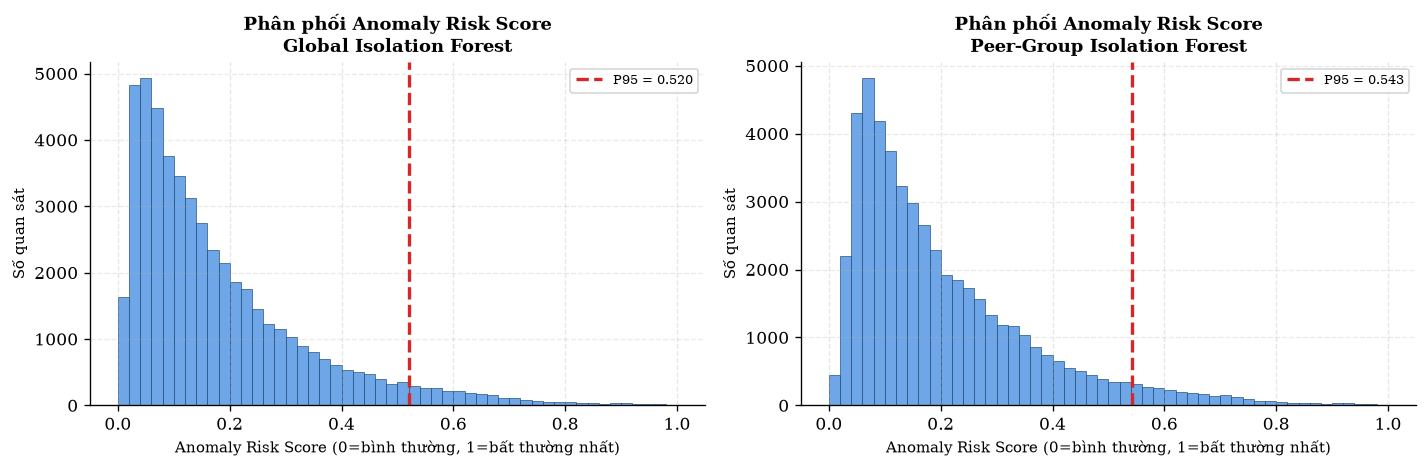

[Saved] fig01_anomaly_risk_score_histogram.png


In [34]:
# ============================================================
#   BIỂU ĐỒ 1: Histogram anomaly_risk_score
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

for ax, (score_col, title) in zip(axes, [
    ('global_anomaly_risk_score', 'Global Isolation Forest'),
    ('peer_anomaly_risk_score',   'Peer-Group Isolation Forest'),
]):
    if score_col not in df_main.columns:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        continue

    data = df_main[score_col].dropna()

    ax.hist(
        data,
        bins=50,
        color='#4A90E2',      # xanh dương
        edgecolor='#1F4E79',  # viền xanh đậm
        alpha=0.8,
        linewidth=0.5
    )

    q95 = data.quantile(0.95)

    ax.axvline(
        q95,
        color='#D62728',      # đỏ cho ngưỡng P95
        ls='--',
        lw=2,
        label=f'P95 = {q95:.3f}'
    )

    ax.set_title(
        f'Phân phối Anomaly Risk Score\n{title}',
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Anomaly Risk Score (0=bình thường, 1=bất thường nhất)',
        fontsize=9
    )

    ax.set_ylabel('Số quan sát', fontsize=9)

    ax.grid(axis='y', alpha=0.25)

    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / 'fig01_anomaly_risk_score_histogram.png',
    dpi=120,
    bbox_inches='tight'
)
plt.show()

print("[Saved] fig01_anomaly_risk_score_histogram.png")

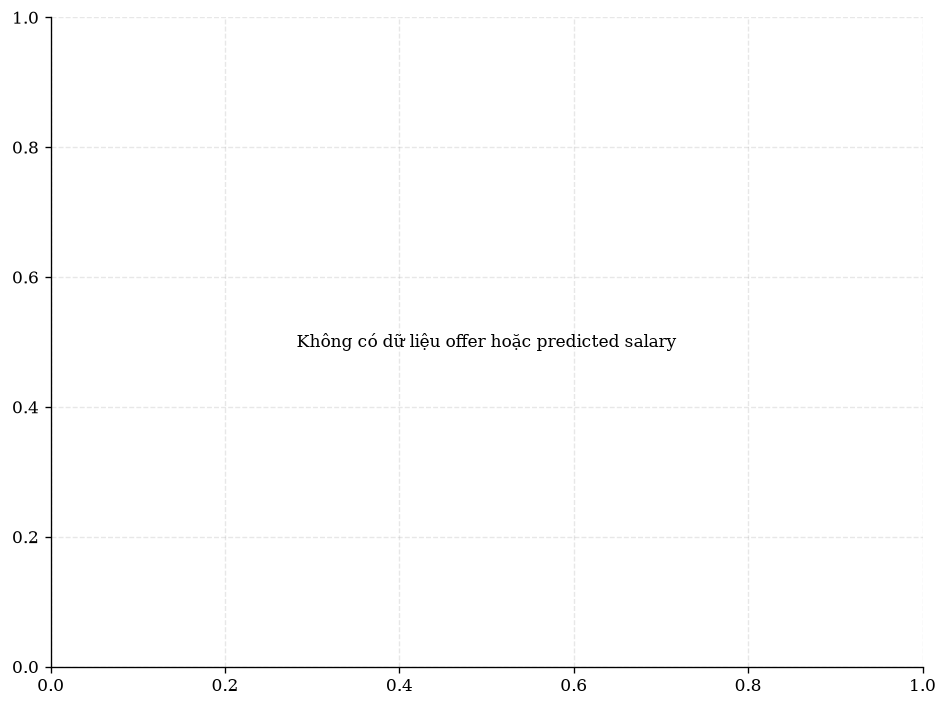

[Saved] fig02_offer_vs_predicted_scatter.png


In [35]:
# ============================================================
#   BIỂU ĐỒ 2: Scatter offer_salary vs predicted_salary
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

if OFFER_COL in df_main.columns and PRED_COL and PRED_COL in df_main.columns:
    offer_vals = np.exp(df_main[OFFER_COL]) if IS_LOG_SCALE else df_main[OFFER_COL]
    pred_vals  = np.exp(df_main[PRED_COL])  if IS_LOG_SCALE else df_main[PRED_COL]

    marker_style = {
        'normal_offer'      : ('o',  'lightgray', 25,  0.4, 'Normal'),
        'underpaid_outlier' : ('v',  'black',     60,  0.9, 'Underpaid'),
        'overpaid_outlier'  : ('^',  'dimgray',   60,  0.9, 'Overpaid'),
        'structural_outlier': ('s',  'darkgray',  50,  0.85, 'Structural'),
    }

    for atype, (marker, color, size, alpha, label) in marker_style.items():
        mask = df_main['anomaly_type'] == atype
        if mask.sum() == 0:
            continue
        ax.scatter(
            pred_vals[mask], offer_vals[mask],
            marker=marker, c=color, s=size, alpha=alpha, label=label, linewidths=0.3,
        )

    # Đường y=x
    lim_min = min(offer_vals.min(), pred_vals.min())
    lim_max = max(offer_vals.max(), pred_vals.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1, label='Offer = Predicted')

    ax.set_xlabel('Predicted Salary (Module 1)', fontsize=10)
    ax.set_ylabel('Offer Salary', fontsize=10)
    ax.set_title('Scatter: Offer Salary vs Predicted Salary theo Anomaly Type', fontsize=11)
    ax.legend(fontsize=8, framealpha=0.7)
else:
    ax.text(0.5, 0.5, 'Không có dữ liệu offer hoặc predicted salary',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig02_offer_vs_predicted_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print("[Saved] fig02_offer_vs_predicted_scatter.png")

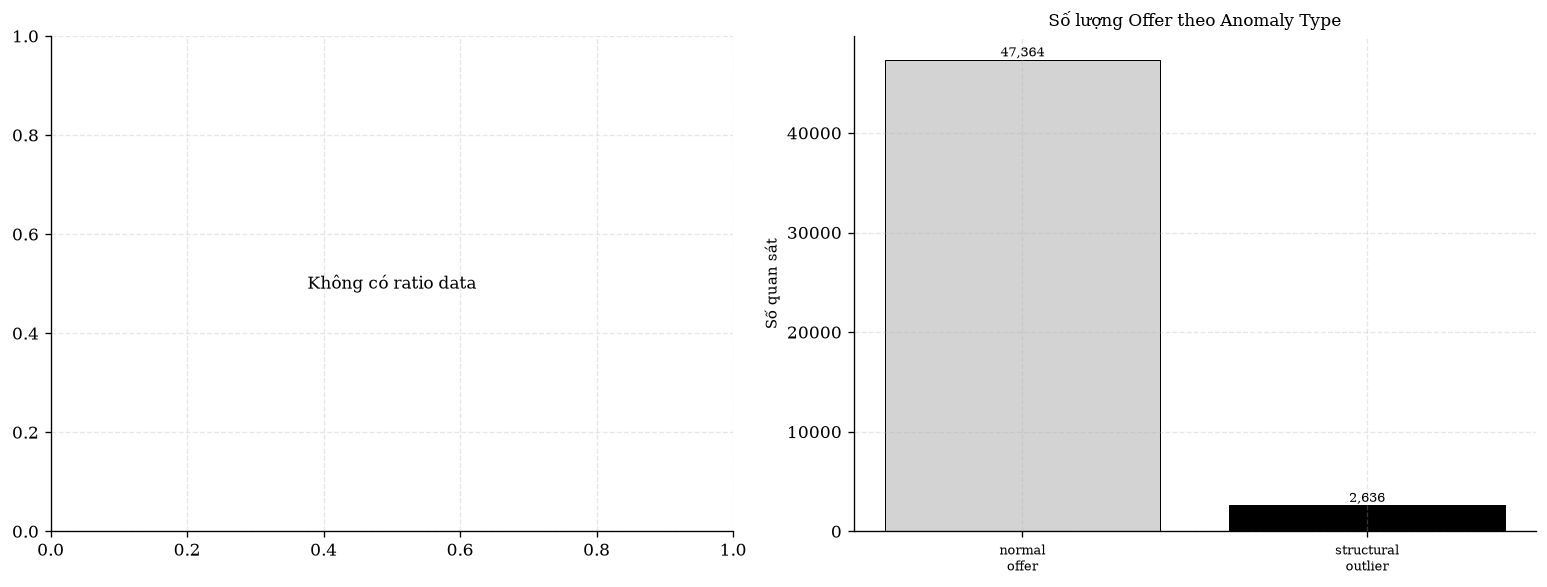

[Saved] fig03_boxplot_and_bar_anomaly_type.png


In [36]:
# ============================================================
#   BIỂU ĐỒ 3: Boxplot offer_to_peer_ratio theo anomaly_type
#   BIỂU ĐỒ 4: Bar chart số lượng anomaly theo loại
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

# ── Boxplot ──
ax = axes[0]
ratio_col = 'offer_to_peer_ratio' if 'offer_to_peer_ratio' in df_main.columns \
            else 'offer_to_predicted_ratio'

if ratio_col in df_main.columns:
    atype_order = ['normal_offer', 'underpaid_outlier', 'overpaid_outlier', 'structural_outlier']
    groups_data = []
    group_labels = []
    for at in atype_order:
        d = df_main.loc[df_main['anomaly_type'] == at, ratio_col].dropna()
        if len(d) > 0:
            groups_data.append(d.values)
            group_labels.append(at.replace('_', '\n'))

    bp = ax.boxplot(
        groups_data, labels=group_labels,
        patch_artist=True, medianprops={'color': 'black', 'linewidth': 1.5},
        boxprops={'facecolor': 'lightgray', 'alpha': 0.8},
        whiskerprops={'linestyle': '--', 'linewidth': 0.8},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    )
    ax.axhline(LOW_RATIO_THRESHOLD,  color='black', ls=':', lw=1, label=f'Low ({LOW_RATIO_THRESHOLD})')
    ax.axhline(HIGH_RATIO_THRESHOLD, color='dimgray', ls=':', lw=1, label=f'High ({HIGH_RATIO_THRESHOLD})')
    ax.axhline(1.0, color='gray', ls='-', lw=0.8, alpha=0.5)
    ax.set_title(f'Phân phối {ratio_col}\ntheo Anomaly Type', fontsize=10)
    ax.set_ylabel('Ratio (offer / benchmark)', fontsize=9)
    ax.legend(fontsize=7)
else:
    ax.text(0.5, 0.5, 'Không có ratio data', ha='center', va='center')

# ── Bar chart ──
ax = axes[1]
type_counts = df_main['anomaly_type'].value_counts()
colors_bar  = ['lightgray', 'black', 'dimgray', 'darkgray']
bars = ax.bar(type_counts.index, type_counts.values,
              color=colors_bar[:len(type_counts)], edgecolor='black', linewidth=0.6)
for bar, cnt in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{cnt:,}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(type_counts)))
ax.set_xticklabels([t.replace('_', '\n') for t in type_counts.index], fontsize=8)
ax.set_title('Số lượng Offer theo Anomaly Type', fontsize=10)
ax.set_ylabel('Số quan sát', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig03_boxplot_and_bar_anomaly_type.png', dpi=120, bbox_inches='tight')
plt.show()
print("[Saved] fig03_boxplot_and_bar_anomaly_type.png")

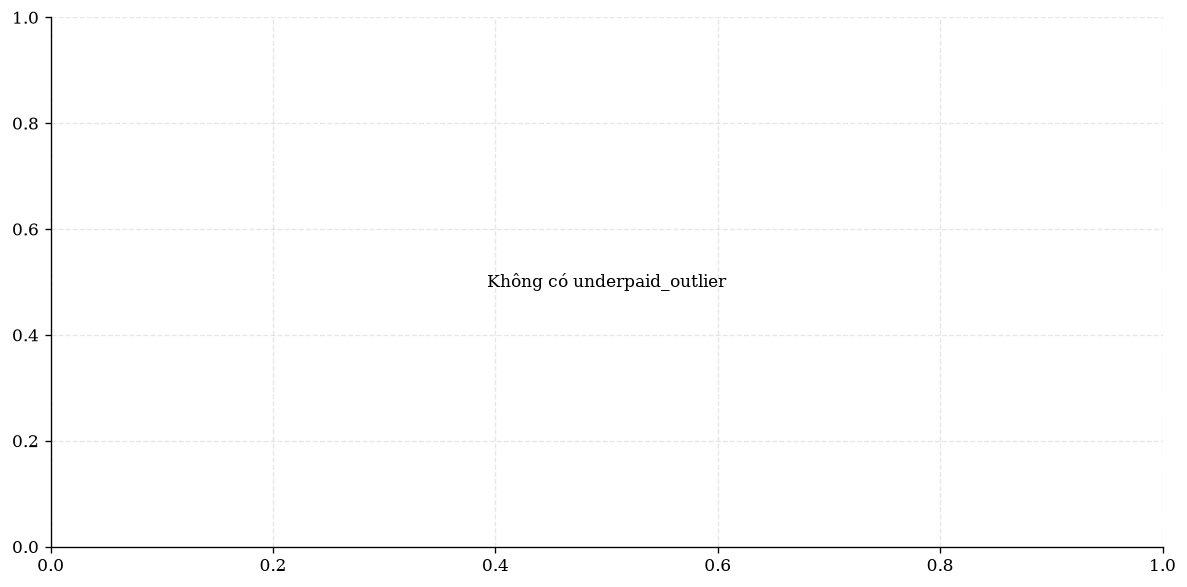

[Saved] fig04_underpaid_by_peer_group.png


In [37]:
# ============================================================
#   BIỂU ĐỒ 5: Top peer groups nhiều underpaid_outlier nhất
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

if 'peer_group_key' in df_main.columns:
    underpaid_by_group = (
        df_main[df_main['anomaly_type'] == 'underpaid_outlier']
        .groupby('peer_group_key')
        .size()
        .sort_values(ascending=False)
        .head(15)
    )
    if len(underpaid_by_group) > 0:
        bars = ax.barh(
            underpaid_by_group.index[::-1],
            underpaid_by_group.values[::-1],
            color='black', edgecolor='white', linewidth=0.4, alpha=0.85
        )
        ax.set_xlabel('Số underpaid_outlier', fontsize=9)
        ax.set_title('Top 15 Peer Group có nhiều Underpaid Outlier nhất', fontsize=10)
        for bar, cnt in zip(bars, underpaid_by_group.values[::-1]):
            ax.text(cnt + 0.1, bar.get_y() + bar.get_height()/2,
                    str(cnt), va='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Không có underpaid_outlier', ha='center', va='center')
else:
    ax.text(0.5, 0.5, 'peer_group_key không tồn tại', ha='center', va='center')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig04_underpaid_by_peer_group.png', dpi=120, bbox_inches='tight')
plt.show()
print("[Saved] fig04_underpaid_by_peer_group.png")

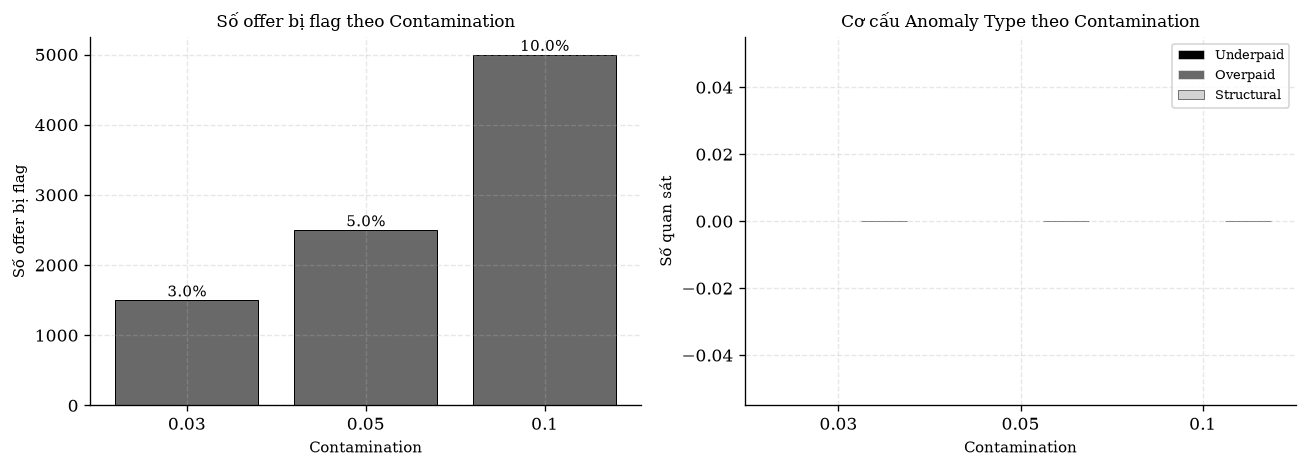

[Saved] fig05_sensitivity_contamination.png


In [38]:
# ============================================================
#   BIỂU ĐỒ 6: Sensitivity Analysis theo contamination
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

# Số offer bị flag
ax = axes[0]
ax.bar(
    [str(c) for c in df_sensitivity['contamination']],
    df_sensitivity['n_flagged'],
    color='dimgray', edgecolor='black', linewidth=0.6
)
for i, (_, row) in enumerate(df_sensitivity.iterrows()):
    ax.text(i, row['n_flagged'] + 1, f"{row['pct_flagged']:.1f}%",
            ha='center', va='bottom', fontsize=9)
ax.set_title('Số offer bị flag theo Contamination', fontsize=10)
ax.set_xlabel('Contamination', fontsize=9)
ax.set_ylabel('Số offer bị flag', fontsize=9)

# Cơ cấu underpaid / overpaid / structural
ax = axes[1]
x = range(len(df_sensitivity))
w = 0.25
ax.bar([i - w for i in x], df_sensitivity['n_underpaid'],   width=w, label='Underpaid',   color='black',   edgecolor='white', linewidth=0.3)
ax.bar([i     for i in x], df_sensitivity['n_overpaid'],    width=w, label='Overpaid',    color='dimgray', edgecolor='white', linewidth=0.3)
ax.bar([i + w for i in x], df_sensitivity['n_structural'],  width=w, label='Structural',  color='lightgray', edgecolor='black', linewidth=0.3)
ax.set_xticks(list(x))
ax.set_xticklabels([str(c) for c in df_sensitivity['contamination']])
ax.set_xlabel('Contamination', fontsize=9)
ax.set_ylabel('Số quan sát', fontsize=9)
ax.set_title('Cơ cấu Anomaly Type theo Contamination', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig05_sensitivity_contamination.png', dpi=120, bbox_inches='tight')
plt.show()
print("[Saved] fig05_sensitivity_contamination.png")

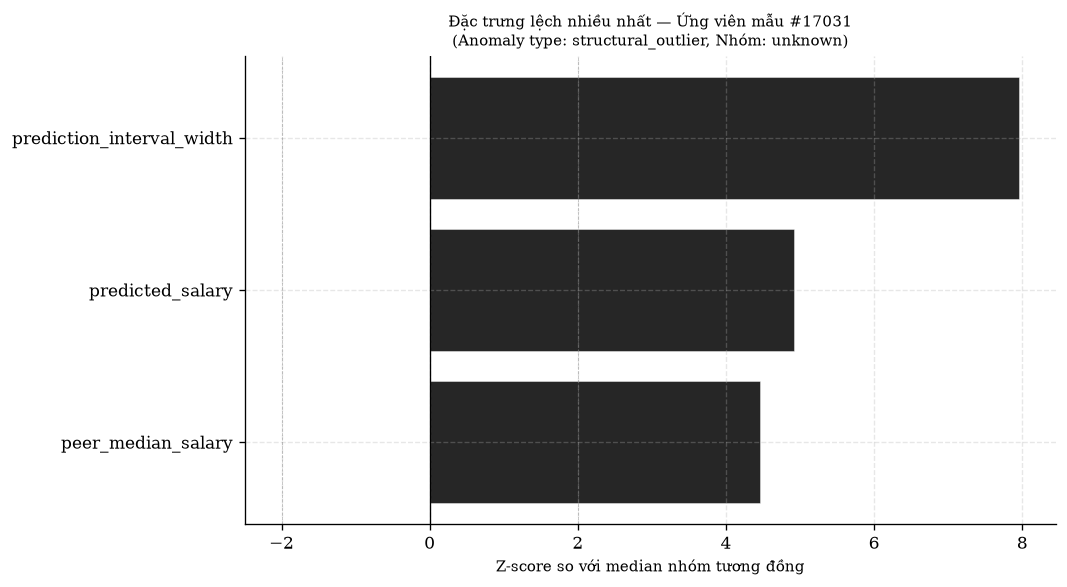

[Saved] fig06_sample_candidate_deviation.png  (idx=17031)


In [39]:
# ============================================================
#   BIỂU ĐỒ 7: Bar plot deviation của ứng viên mẫu
# ============================================================

# Chọn ứng viên mẫu: underpaid_outlier với anomaly score cao nhất
sample_mask = df_main['anomaly_type'] == 'underpaid_outlier'
if not sample_mask.any():
    sample_mask = df_main['anomaly_type'] != 'normal_offer'

if sample_mask.any():
    sample_idx = df_main.loc[sample_mask, 'global_anomaly_risk_score'].idxmax()
    sample_row  = df_features.loc[sample_idx] if sample_idx in df_features.index else None

    if sample_row is not None:
        grp_key = df_main.loc[sample_idx, 'peer_group_key'] if 'peer_group_key' in df_main.columns else 'GLOBAL'
        if grp_key != 'GLOBAL_FALLBACK' and 'peer_group_key' in df_main.columns:
            ref_df = df_features[df_main['peer_group_key'] == grp_key]
        else:
            ref_df = df_features

        df_dev = explain_anomaly_by_deviation(sample_row, ref_df, FEATURE_NAMES, top_n=10)

        fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
        colors_bar = ['black' if z > 0 else 'dimgray' for z in df_dev['z_score']]
        bars = ax.barh(
            df_dev['feature'][::-1], df_dev['z_score'][::-1],
            color=colors_bar[::-1], edgecolor='white', linewidth=0.3, alpha=0.85
        )
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline( 2, color='gray', lw=0.5, ls='--', alpha=0.5)
        ax.axvline(-2, color='gray', lw=0.5, ls='--', alpha=0.5)
        ax.set_xlabel('Z-score so với median nhóm tương đồng', fontsize=9)
        ax.set_title(
            f'Đặc trưng lệch nhiều nhất — Ứng viên mẫu #{sample_idx}\n'
            f'(Anomaly type: {df_main.loc[sample_idx, "anomaly_type"]}, '
            f'Nhóm: {grp_key[:50]})',
            fontsize=9
        )
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / 'fig06_sample_candidate_deviation.png', dpi=120, bbox_inches='tight')
        plt.show()
        print(f"[Saved] fig06_sample_candidate_deviation.png  (idx={sample_idx})")
    else:
        print("[WARN] Không tìm thấy dữ liệu feature cho ứng viên mẫu.")
else:
    print("[WARN] Không có ứng viên bất thường để vẽ biểu đồ 7.")

---
## Cell 13 — Hàm tư vấn cho từng ứng viên

Hai hàm chính phục vụ chatbot / API:
- `analyze_offer_anomaly()` → dict JSON-serializable
- `generate_offer_anomaly_explanation()` → chuỗi văn bản tự nhiên

In [40]:
# ============================================================
#   FUNCTION: analyze_offer_anomaly(candidate_index, candidate_id)
# ============================================================

def analyze_offer_anomaly(
    candidate_index: int   = None,
    candidate_id:    object = None,
    df:              pd.DataFrame = None,
    df_feat:         pd.DataFrame = None,
) -> dict:
    """
    Trả về thông tin anomaly đầy đủ cho một ứng viên.

    Parameters
    ----------
    candidate_index : vị trí (iloc) trong df
    candidate_id    : giá trị ID nếu có cột CANDIDATE_ID_COL

    Returns
    -------
    dict với các trường: candidate_id, offer_salary, predicted_salary,
    peer_median_salary, anomaly_type, anomaly_risk_score, suggested_action,
    top_deviation_features, explanation_text
    """
    _df    = df    if df    is not None else df_main
    _dfeat = df_feat if df_feat is not None else df_features

    # Tìm dòng
    if candidate_id is not None and CANDIDATE_ID_COL and CANDIDATE_ID_COL in _df.columns:
        matches = _df[_df[CANDIDATE_ID_COL] == candidate_id]
        if len(matches) == 0:
            raise ValueError(f"Không tìm thấy candidate_id={candidate_id}")
        idx = matches.index[0]
    elif candidate_index is not None:
        idx = _df.index[candidate_index]
    else:
        raise ValueError("Phải cung cấp candidate_index hoặc candidate_id.")

    row = _df.loc[idx]

    # Đọc các giá trị cơ bản
    def safe_val(col, exp_transform=False):
        if col and col in row.index and pd.notna(row[col]):
            v = float(row[col])
            return round(np.exp(v), 2) if (exp_transform and IS_LOG_SCALE) else round(v, 4)
        return None

    offer_salary       = safe_val(OFFER_COL, exp_transform=True)
    predicted_salary   = safe_val(PRED_COL,  exp_transform=True)
    peer_median_salary = safe_val(PEER_MEDIAN_COL, exp_transform=True)
    global_risk        = safe_val('global_anomaly_risk_score')
    peer_risk          = safe_val('peer_anomaly_risk_score')
    anomaly_type       = row.get('anomaly_type', 'unknown')

    # Suggested action
    action, explanation = get_suggested_action(anomaly_type)

    # Top deviation features
    grp_key = row.get('peer_group_key', 'GLOBAL_FALLBACK')
    if grp_key and grp_key != 'GLOBAL_FALLBACK' and 'peer_group_key' in _df.columns:
        ref_df = _dfeat[_df['peer_group_key'] == grp_key]
    else:
        ref_df = _dfeat

    row_feat = _dfeat.loc[idx] if idx in _dfeat.index else pd.Series(dtype=float)
    df_dev   = explain_anomaly_by_deviation(row_feat, ref_df, FEATURE_NAMES, top_n=5)
    top_feats = df_dev[['feature', 'z_score', 'candidate_val', 'group_median']].to_dict('records')

    return {
        'candidate_id'          : row.get(CANDIDATE_ID_COL, idx) if CANDIDATE_ID_COL else idx,
        'offer_salary'          : offer_salary,
        'predicted_salary'      : predicted_salary,
        'peer_median_salary'    : peer_median_salary,
        'anomaly_type'          : anomaly_type,
        'global_anomaly_risk'   : global_risk,
        'peer_anomaly_risk'     : peer_risk,
        'peer_group_key'        : grp_key,
        'suggested_action'      : action,
        'top_deviation_features': top_feats,
        'explanation_summary'   : explanation,
    }


# ============================================================
#   FUNCTION: generate_offer_anomaly_explanation()
# ============================================================

def generate_offer_anomaly_explanation(
    candidate_index: int    = None,
    candidate_id:    object = None,
) -> str:
    """
    Sinh đoạn văn giải thích tự nhiên về kết quả anomaly của một ứng viên.

    Returns
    -------
    str — đoạn giải thích dạng ngôn ngữ tự nhiên
    """
    info = analyze_offer_anomaly(candidate_index=candidate_index, candidate_id=candidate_id)

    cid    = info['candidate_id']
    atype  = info['anomaly_type']
    offer  = info['offer_salary']
    pred   = info['predicted_salary']
    peer   = info['peer_median_salary']
    risk   = info['global_anomaly_risk']
    action = info['suggested_action']
    grp    = info['peer_group_key']
    feats  = info['top_deviation_features']

    # Xây dựng câu giải thích
    type_desc = {
        'underpaid_outlier'  : 'bất thường — mức lương THẤP so với nhóm tương đồng',
        'overpaid_outlier'   : 'bất thường — mức lương CAO so với nhóm tương đồng',
        'structural_outlier' : 'bất thường về cấu trúc hồ sơ (không phải lương thấp hay cao rõ rệt)',
        'normal_offer'       : 'trong vùng bình thường',
    }
    desc = type_desc.get(atype, 'không xác định')

    text = f"""📊 KẾT QUẢ PHÂN TÍCH ANOMALY — Ứng viên #{cid}
{'='*60}
Đánh giá tổng thể: Offer được phân loại là {desc.upper()}.

• Mức lương offer    : {f'{offer:,.0f}' if offer else 'N/A'}
• Dự báo mô hình (P50): {f'{pred:,.0f}' if pred else 'N/A'}
• Median nhóm tương đồng: {f'{peer:,.0f}' if peer else 'N/A'}
• Anomaly risk score : {risk:.4f} (0=bình thường, 1=bất thường nhất)
• Nhóm tương đồng   : {grp}
"""

    # Tính chênh lệch %
    if offer and pred:
        pct_vs_pred = (offer - pred) / pred * 100
        text += f"  → Offer {'cao hơn' if pct_vs_pred > 0 else 'thấp hơn'} dự báo {abs(pct_vs_pred):.1f}%\n"
    if offer and peer:
        pct_vs_peer = (offer - peer) / peer * 100
        text += f"  → Offer {'cao hơn' if pct_vs_peer > 0 else 'thấp hơn'} median nhóm {abs(pct_vs_peer):.1f}%\n"

    if feats:
        text += "\n🔍 Đặc trưng lệch nhiều nhất so với nhóm:\n"
        for f in feats:
            direction = "cao hơn" if f['z_score'] > 0 else "thấp hơn"
            text += (f"  • {f['feature']:30s}: giá trị={f['candidate_val']:.3f}, "
                     f"median nhóm={f['group_median']:.3f}, "
                     f"z={f['z_score']:.2f} ({direction} chuẩn)\n")

    text += f"\n✅ Khuyến nghị: {action}\n"
    text += "\n⚠️  Lưu ý: Kết quả Isolation Forest phản ánh bất thường THỐNG KÊ, không kết luận offer sai. Cần kiểm tra thêm bởi chuyên gia nhân sự."

    return text


# Demo với ứng viên đầu tiên
print(generate_offer_anomaly_explanation(candidate_index=0))

📊 KẾT QUẢ PHÂN TÍCH ANOMALY — Ứng viên #-2502.52510935755
Đánh giá tổng thể: Offer được phân loại là TRONG VÙNG BÌNH THƯỜNG.

• Mức lương offer    : N/A
• Dự báo mô hình (P50): 93,685
• Median nhóm tương đồng: 97,618
• Anomaly risk score : 0.2808 (0=bình thường, 1=bất thường nhất)
• Nhóm tương đồng   : unknown

🔍 Đặc trưng lệch nhiều nhất so với nhóm:
  • peer_median_salary            : giá trị=97618.000, median nhóm=143988.000, z=-1.44 (thấp hơn chuẩn)
  • predicted_salary              : giá trị=93684.525, median nhóm=143580.829, z=-1.35 (thấp hơn chuẩn)
  • prediction_interval_width     : giá trị=11693.201, median nhóm=12912.183, z=-0.45 (thấp hơn chuẩn)

✅ Khuyến nghị: EVALUATE_BY_STANDARD_RULE

⚠️  Lưu ý: Kết quả Isolation Forest phản ánh bất thường THỐNG KÊ, không kết luận offer sai. Cần kiểm tra thêm bởi chuyên gia nhân sự.


In [41]:
# Demo với ứng viên underpaid nhất (nếu có)
if 'underpaid_outlier' in df_main['anomaly_type'].values:
    underpaid_idx = df_main[df_main['anomaly_type'] == 'underpaid_outlier']['global_anomaly_risk_score'].idxmax()
    pos = df_main.index.get_loc(underpaid_idx)
    print(generate_offer_anomaly_explanation(candidate_index=pos))

---
## Cell 14 — Xuất báo cáo Markdown

In [42]:
# ============================================================
#   FUNCTION: export_offer_anomaly_report()
# ============================================================

def export_offer_anomaly_report() -> str:
    """Tạo báo cáo Markdown tóm tắt toàn bộ Module 8."""

    type_counts  = df_main['anomaly_type'].value_counts()
    n_total      = len(df_main)
    n_anomaly    = (df_main['anomaly_type'] != 'normal_offer').sum()

    # Ứng viên mẫu
    sample_text = "Không có trường hợp bất thường."
    if n_anomaly > 0:
        try:
            mask    = df_main['anomaly_type'] != 'normal_offer'
            top_idx = df_main.loc[mask, 'global_anomaly_risk_score'].idxmax()
            pos     = df_main.index.get_loc(top_idx)
            sample_text = generate_offer_anomaly_explanation(candidate_index=pos)
        except Exception as e:
            sample_text = f"Không thể tạo ví dụ: {e}"

    # Sensitivity table
    sens_md = df_sensitivity.to_markdown(index=False) if hasattr(df_sensitivity, 'to_markdown') \
              else df_sensitivity.to_string(index=False)

    report = f"""# Module 8 — Báo cáo Phát hiện Offer Bất thường

## 1. Mục tiêu
Phát hiện các offer lương bất thường trong dữ liệu tuyển dụng bằng **Isolation Forest** (hai tầng: Global và Peer-Group), phân loại thành `underpaid_outlier`, `overpaid_outlier`, `structural_outlier`, `normal_offer`, và sinh diễn giải hỗ trợ tư vấn đàm phán lương.

## 2. Dữ liệu sử dụng
- File chính : `{DATA_PATH}`
- Peer benchmark : {'Có' if optional_tables.get('peer_benchmark') is not None else 'Không tìm thấy'}
- Offer assessment: {'Có' if optional_tables.get('offer_assessment') is not None else 'Không tìm thấy'}
- Số quan sát  : {n_total:,}
- Target scale : {'Log (ln_salary)' if IS_LOG_SCALE else 'Tuyến tính (salary)'}

## 3. Feature sử dụng cho Isolation Forest
```
{chr(10).join(FEATURE_NAMES)}
```

## 4. Kết quả phát hiện bất thường
- **Contamination mặc định**: {DEFAULT_CONTAMINATION}
- **Tổng offer bị flag**: {n_anomaly:,} / {n_total:,} ({100*n_anomaly/n_total:.1f}%)

| Anomaly Type | Số lượng | Tỷ lệ |
|---|---|---|
{''.join(f'| {t} | {c:,} | {100*c/n_total:.1f}% |{chr(10)}' for t, c in type_counts.items())}

## 5. Ví dụ diễn giải — Ứng viên có Risk Score cao nhất

```
{sample_text}
```

## 6. Sensitivity Analysis

{sens_md}

## 7. Giới hạn phương pháp

1. **Isolation Forest chỉ phát hiện bất thường thống kê**, không chứng minh offer sai hay gian lận.
2. Kết quả phụ thuộc vào:
   - Chất lượng và đại diện của dữ liệu huấn luyện
   - Tham số `contamination` (xem sensitivity analysis)
   - Chất lượng peer benchmark từ Module 2
   - Các feature đặc trưng được chọn
3. **Các offer bị flag cần được kiểm tra bởi chuyên gia nhân sự** trước khi đưa ra quyết định.
4. Nhóm nhỏ hơn {MIN_GROUP_SIZE} quan sát sẽ fallback sang Global model, có thể kém chính xác hơn.
5. Module không xét đến yếu tố thị trường lao động theo thời gian (chỉ dùng dữ liệu tĩnh).

## 8. File output

| File | Nội dung |
|---|---|
| `tables/table_01_input_summary.csv` | Tóm tắt dữ liệu đầu vào |
| `tables/table_02_anomaly_features_used.csv` | Feature sử dụng |
| `tables/table_03_global_anomaly_results.csv` | Kết quả Global IF |
| `tables/table_04_peer_group_anomaly_results.csv` | Kết quả Peer-Group IF |
| `tables/table_05_peer_group_summary.csv` | Thống kê từng peer group |
| `tables/table_06_anomaly_classification.csv` | Phân loại anomaly type |
| `tables/table_07_offer_anomaly_decision_support.csv` | Bảng tư vấn |
| `tables/table_08_anomaly_explanation.csv` | Diễn giải feature lệch |
| `tables/table_09_contamination_sensitivity.csv` | Sensitivity analysis |
| `models/global_isolation_forest.joblib` | Model Global IF |
| `models/peer_group_isolation_forests.joblib` | Models Peer-Group IF |
| `models/anomaly_preprocessing_pipeline.joblib` | Preprocessing pipeline |
"""

    report_path = OUTPUT_DIR / "module_08_offer_anomaly_report.md"
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)

    print(f"[Saved] {report_path}")
    return str(report_path)


report_path = export_offer_anomaly_report()
print("\n[OK] Báo cáo đã được xuất.")

[Saved] module_08_offer_anomaly\module_08_offer_anomaly_report.md

[OK] Báo cáo đã được xuất.


---
## Cell 15 — Tổng kết: Danh sách hàm chính

Tất cả hàm đã được định nghĩa và sẵn sàng tái sử dụng:

In [43]:
# ============================================================
#   TỔNG KẾT: DANH SÁCH HÀM CHÍNH MODULE 8
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║      MODULE 8 — HÀM CHÍNH (ĐÃ SẴN SÀNG TÁI SỬ DỤNG)       ║
╚══════════════════════════════════════════════════════════════╝

1. build_anomaly_features(df, offer_col, pred_col, peer_median_col, is_log_scale)
   → Tạo ma trận đặc trưng X cho Isolation Forest (+ impute + scale)

2. fit_global_isolation_forest(X, contamination=0.05)
   → Huấn luyện Global IF, trả về model + anomaly_risk_score toàn cục

3. fit_peer_group_isolation_forest(df, X, group_cols=None, contamination=0.05)
   → Huấn luyện IF theo peer group, tự động fallback khi nhóm nhỏ

4. classify_offer_anomaly(row)
   → Gắn nhãn: underpaid_outlier / overpaid_outlier / structural_outlier / normal_offer

5. explain_anomaly_by_deviation(row_features, reference_profile, feature_names)
   → Diễn giải feature lệch nhiều nhất theo z-score trong nhóm

6. analyze_offer_anomaly(candidate_index=None, candidate_id=None)
   → Dict JSON-serializable đầy đủ cho một ứng viên

7. generate_offer_anomaly_explanation(candidate_index=None, candidate_id=None)
   → Đoạn văn giải thích tự nhiên (dùng cho chatbot / báo cáo)

8. run_contamination_sensitivity(X, df_base, grid=[0.03, 0.05, 0.10])
   → So sánh kết quả với nhiều contamination

9. export_offer_anomaly_report()
   → Xuất báo cáo Markdown tóm tắt toàn module
""")

print("\n📁 Output files:")
for f in sorted(OUTPUT_DIR.rglob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.relative_to(OUTPUT_DIR)}  ({size_kb:.1f} KB)")


╔══════════════════════════════════════════════════════════════╗
║      MODULE 8 — HÀM CHÍNH (ĐÃ SẴN SÀNG TÁI SỬ DỤNG)       ║
╚══════════════════════════════════════════════════════════════╝

1. build_anomaly_features(df, offer_col, pred_col, peer_median_col, is_log_scale)
   → Tạo ma trận đặc trưng X cho Isolation Forest (+ impute + scale)

2. fit_global_isolation_forest(X, contamination=0.05)
   → Huấn luyện Global IF, trả về model + anomaly_risk_score toàn cục

3. fit_peer_group_isolation_forest(df, X, group_cols=None, contamination=0.05)
   → Huấn luyện IF theo peer group, tự động fallback khi nhóm nhỏ

4. classify_offer_anomaly(row)
   → Gắn nhãn: underpaid_outlier / overpaid_outlier / structural_outlier / normal_offer

5. explain_anomaly_by_deviation(row_features, reference_profile, feature_names)
   → Diễn giải feature lệch nhiều nhất theo z-score trong nhóm

6. analyze_offer_anomaly(candidate_index=None, candidate_id=None)
   → Dict JSON-serializable đầy đủ cho một ứng viên

